# TP: Building an MLP from Scratch for CIFAR-10 Classification

_Adapted from [Dataflowr Module 5](https://dataflowr.github.io/website/modules/5-stacking-layers/#practicals) by Marc Lelarge_

In this practical, you will implement a Multi-Layer Perceptron (MLP) from scratch using PyTorch to classify images from the CIFAR-10 dataset.

## System Setup

Import the required packages and check PyTorch version.

In [25]:
import torch
from torchvision import datasets, transforms

print('Pytorch version: ', torch.__version__)

Pytorch version:  2.10.0+cpu


## Part 1: Building the Dataset

### About CIFAR-10

CIFAR-10 is a dataset of 32x32 color images in 10 classes:
- **Classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- **Training images**: 50,000 (5,000 per class)
- **Test images**: 10,000 (1,000 per class)
- **Image size**: 32x32 pixels, RGB (3 channels)

### Data Preprocessing

For an MLP, we need to:
1. Convert images to tensors
2. Normalize pixel values (mean=0.5, std=0.5 for each channel)
3. Flatten 32x32x3 images into 1D vectors of size 3072

**TODO 1:** Create a transform pipeline using `transforms.Compose` that:
- Converts images to tensors with `transforms.ToTensor()`
- Normalizes with `transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))`

In [26]:
normalize = transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))

transform = transforms.Compose([
    transforms.ToTensor(),
    normalize,
])

### Loading CIFAR-10 Dataset

**TODO 2:** Load the CIFAR-10 dataset using `datasets.CIFAR10`.

Hints:
- Set `root='./data'` to specify download directory
- Set `train=True` for training set, `train=False` for test set
- Set `download=True` to download the dataset
- Use the transform pipeline you created above

Check the documentation: [datasets.CIFAR10](https://pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html)

In [27]:
train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

### Check Dataset Properties

**TODO 3:** Print the sizes of training and test datasets, and examine the class names.

In [28]:
print(f"size of training set: {len(train_data)})")
print(f"size of test set: {len(test_data)})")

size of training set: 50000)
size of test set: 10000)


### Creating DataLoaders

DataLoaders handle batching, shuffling, and parallel loading of data.

**TODO 4:** Create DataLoaders for training and testing.

Hints:
- Use `batch_size=128` for training
- Use `batch_size=100` for testing
- Set `shuffle=True` for training data
- Set `shuffle=False` for test data
- Set `num_workers=2` for parallel data loading

Check the documentation: [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)

In [29]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=100, shuffle=False, num_workers=2)


### Visualize Sample Images

**TODO 5:** Visualize a batch of training images using matplotlib.

Hints:
- Get a batch using `next(iter(train_loader))`
- Use `torchvision.utils.make_grid()` to create a grid of images
- Don't forget to denormalize before displaying (reverse the normalization)

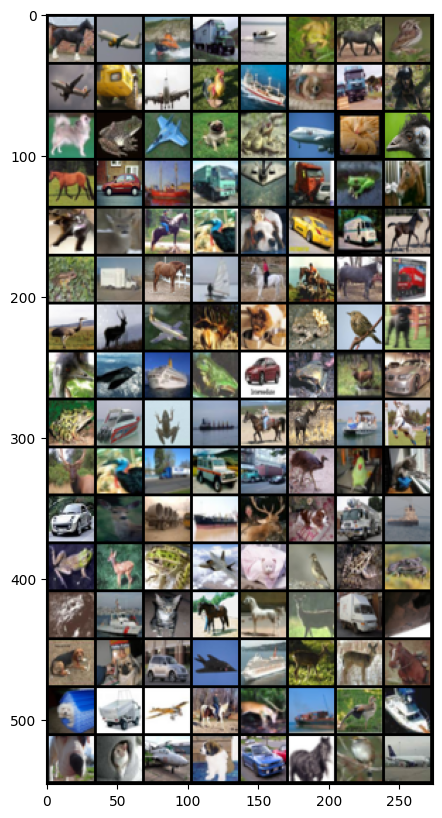

In [30]:
import matplotlib.pyplot as plt
import torchvision

inputs, labels = next(iter(train_loader))

mean = torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1) #对齐维度！
std = torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1)

inputs_denormalize = inputs * std + mean #逆运算：$x = x_{std} \cdot \sigma + \mu$。

plt.figure(figsize=(10, 10))
grid = torchvision.utils.make_grid(inputs_denormalize, nrow=8)
plt.imshow(grid.permute(1, 2, 0)) #pytorch图片格式是CHW, imshow需要HWC
plt.show()

## Part 2: Understanding MLP Architecture

### What is an MLP?

A Multi-Layer Perceptron (MLP) is a fully connected neural network consisting of:
- **Input layer**: Takes flattened input (3072 values for 32x32x3 images)
- **Hidden layers**: One or more layers that learn features
- **Output layer**: Produces class probabilities (10 values for CIFAR-10)

### Architecture Design

We will build an MLP with the following structure:

```
Input: 32x32x3 image → Flatten → 3072 values
   ↓
Linear(3072 → 1000)  [Weights: 3072×1000 + 1000 bias = 3,073,000 parameters]
   ↓
ReLU activation
   ↓
Linear(1000 → 10)    [Weights: 1000×10 + 10 bias = 10,010 parameters]
   ↓
Output: 10 class scores
```

**Total parameters**: ~3.08 million

### Understanding Dimensions

Each linear layer performs: `output = input @ weights.T + bias`

For a batch of size B:
- Input shape: `[B, 3072]`
- After first linear: `[B, 1000]`
- After second linear: `[B, 10]`

### Non-Linear Activation Functions

**Why do we need activation functions?**

Without non-linearity, stacking multiple linear layers is equivalent to a single linear layer:
```
Layer1(Layer2(x)) = W1(W2*x + b2) + b1 = (W1*W2)*x + (W1*b2 + b1) = W3*x + b3
```

**ReLU (Rectified Linear Unit)**: `ReLU(x) = max(0, x)`
- Introduces non-linearity
- Computationally efficient
- Helps avoid vanishing gradient problem
- Most commonly used activation function

## Part 3: Building the MLP with PyTorch

### Using nn.Sequential

PyTorch provides `nn.Sequential` to stack layers sequentially. This is convenient for simple architectures.

**TODO 6:** Build the MLP model using `nn.Sequential` with:
1. `nn.Flatten()` - converts [B, 3, 32, 32] to [B, 3072]
2. `nn.Linear(3072, 1000)` - hidden layer
3. `nn.ReLU()` - activation function
4. `nn.Linear(1000, 10)` - output layer

Check the documentation:
- [nn.Sequential](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)
- [nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)
- [nn.ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html)

In [31]:
from torch import nn

class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Flatten(),
        nn.Linear(3072,1000),
        nn.ReLU(),
        nn.Linear(1000,10)
    )

  def forward(self,x):
    return self.layers(x)

### Verify Model Architecture

**TODO 7:** Print the model architecture and count the total number of parameters.

Hints:
- Print the model to see its structure
- Use `sum(p.numel() for p in model.parameters())` to count parameters

In [32]:
model = MLP()

print("Model Structure: ", model)
num_params = sum(p.numel() for p in model.parameters())
print("Total Parameters: ", num_params)

Model Structure:  MLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=1000, bias=True)
    (2): ReLU()
    (3): Linear(in_features=1000, out_features=10, bias=True)
  )
)
Total Parameters:  3083010


### Test Forward Pass

**TODO 8:** Test the model with a random batch to verify dimensions.

Hints:
- Create a random tensor of shape `[4, 3, 32, 32]` (batch of 4 images)
- Pass it through the model
- Verify output shape is `[4, 10]`

In [33]:
test_tensor = torch.ones([4,3,32,32])
test_output = model(test_tensor)
print(test_output.shape)

torch.Size([4, 10])


## Part 4: Training the MLP

### Loss Function and Optimizer

**Loss Function**: We use Cross-Entropy Loss for multi-class classification
- Combines `LogSoftmax` and `NLLLoss`
- Measures the difference between predicted probabilities and true labels

**Optimizer**: We use Stochastic Gradient Descent (SGD)
- Updates weights in the direction that reduces loss
- Momentum helps accelerate convergence

**TODO 9:** Create the loss function and optimizer.

Hints:
- Use `nn.CrossEntropyLoss()`
- Use `torch.optim.SGD` with:
  - `lr=0.01` (learning rate)
  - `momentum=0.9`
  - `model.parameters()` to optimize all parameters

Check the documentation:
- [nn.CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
- [torch.optim.SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html)

In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.01,momentum=0.9)

### Training Loop

The training loop consists of:
1. **Forward pass**: Compute predictions
2. **Loss computation**: Calculate error
3. **Backward pass**: Compute gradients using `loss.backward()`
4. **Optimizer step**: Update weights using `optimizer.step()`
5. **Zero gradients**: Clear gradients with `optimizer.zero_grad()`

**TODO 10:** Implement the training function.

Hints:
- Set model to training mode: `model.train()`
- Loop over batches from the dataloader
- Move data to device (GPU/CPU)
- Perform forward pass, compute loss, backward pass, optimizer step
- Track running loss and accuracy
- Use `torch.max(outputs, 1)` to get predicted classes

In [35]:

def train(model, train_loader, criterion, optimizer, epochs):
  model.train()
  current_loss = 0
  for epoch in range(epochs):
    current_loss = 0
    correct_total = 0

    for inputs, labels in train_loader:
      optimizer.zero_grad()
      preds = model(inputs)
      loss = criterion(preds, labels)
      loss.backward()
      optimizer.step()

      current_loss += loss.item()
      _, predicted_idx = torch.max(preds,1)
      correct_total += (predicted_idx == labels).sum().item()

    avg_loss = current_loss / len(train_loader)
    accuracy = correct_total / len(train_loader.dataset)
    print(f"Epoch {epoch}: Loss {avg_loss:.4f}, Acc {accuracy:.4f}")

### Train the Model

**TODO 11:** Train the model for 10 epochs.

Note: Training may take several minutes depending on your hardware.

In [36]:
train(model, train_loader=train_loader, criterion=criterion, optimizer=optimizer,epochs=10)


Epoch 0: Loss 1.6853, Acc 0.4094
Epoch 1: Loss 1.4538, Acc 0.4919
Epoch 2: Loss 1.3511, Acc 0.5268
Epoch 3: Loss 1.2715, Acc 0.5578
Epoch 4: Loss 1.2053, Acc 0.5849
Epoch 5: Loss 1.1393, Acc 0.6082
Epoch 6: Loss 1.0866, Acc 0.6242
Epoch 7: Loss 1.0241, Acc 0.6473
Epoch 8: Loss 0.9822, Acc 0.6637
Epoch 9: Loss 0.9290, Acc 0.6799


## Part 5: Model Evaluation

### Test Function

**TODO 12:** Implement a function to evaluate the model on the test set.

Hints:
- Set model to evaluation mode: `model.eval()`
- Use `torch.no_grad()` to disable gradient computation
- Calculate test loss and accuracy
- Store predictions and probabilities for analysis

In [37]:
def test(model,criterion,test_loader):
  model.eval()

  with torch.no_grad():
    total_loss = 0
    total_correct = 0

    for inputs, labels in test_loader:
      preds = model(inputs)
      loss = criterion(preds, labels)

      total_loss += loss.item()

      _, predicted_idx = torch.max(preds, 1)
      total_correct += (predicted_idx == labels).sum().item()

  avg_loss = total_loss / len(test_loader)
  accuracy = total_correct / len(test_loader.dataset)
  return avg_loss, accuracy

### Evaluate on Test Set

**TODO 13:** Run the test function and report accuracy.

In [38]:
test(model, criterion=criterion,test_loader=test_loader)

(1.4230253112316131, 0.5315)

## Next?

What happens if you
- switch the training to a GPU? Is it faster?
- Remove the `ReLU()`?
- Increase the learning rate?
- Stack more layers?
- Perform more epochs?